# Apresentação: Pipeline de Features (Two-Stage)

Este notebook carrega e apresenta os resultados gerados pelo pipeline de extração de features em duas etapas:

- **Stage A** → YOLO (detecção de objetos) + FER (emoções faciais) + cores + crops salvos em disco.
- **Stage B** → OCR (EasyOCR) + Embeddings textuais (Sentence‑Transformers).

Paths esperados (ambiente docker compose):
- `.../features/stage_a_raw_parquet` — saída da Stage A (detecções + crops).
- `.../features/features_raw_parquet` — saída da Stage B (OCR + embeddings).
- `.../features.parquet` — versão explodida/normalizada pós‑processada.

In [1]:
# Imports e configurações iniciais
import os, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from matplotlib.patches import Rectangle
from io import BytesIO

sns.set(style="whitegrid")
%matplotlib inline

print("Imports OK")

Imports OK


In [2]:
# Parâmetros de caminho
IMAGES_DIR = "/workspace/data/images"
CROPS_DIR = "/workspace/data/output/crops"
STAGE_A_PARQUET = "/workspace/data/output/features/stage_a_raw_parquet"
STAGE_B_PARQUET = "/workspace/data/output/features/features_raw_parquet"
FINAL_PARQUET = "/workspace/data/output/features.parquet"
METADATA_PATH = "/workspace/data/metadata_consolidated.csv"

for name, p in [
    ("IMAGES_DIR", IMAGES_DIR),
    ("CROPS_DIR", CROPS_DIR),
    ("STAGE_A_PARQUET", STAGE_A_PARQUET),
    ("STAGE_B_PARQUET", STAGE_B_PARQUET),
    ("FINAL_PARQUET", FINAL_PARQUET),
]:
    exists = os.path.exists(p)
    print(f"{name}: {p}  →  exists={exists}")

IMAGES_DIR: /workspace/data/images  →  exists=True
CROPS_DIR: /workspace/data/output/crops  →  exists=True
STAGE_A_PARQUET: /workspace/data/output/features/stage_a_raw_parquet  →  exists=True
STAGE_B_PARQUET: /workspace/data/output/features/features_raw_parquet  →  exists=True
FINAL_PARQUET: /workspace/data/output/features.parquet  →  exists=False


In [3]:
# Smart loader: tenta FINAL -> STAGE_B -> STAGE_A em ordem
def _safe_json_load(x):
    if x is None:
        return []
    if isinstance(x, (list, dict)):
        return x
    if isinstance(x, str):
        x = x.strip()
        if not x:
            return []
        try:
            return json.loads(x)
        except Exception:
            return []
    return []

def _explode_json_column(df, col_name):
    """Explode a coluna JSON (lista de dicts) em uma linha por detecção."""
    rows = []
    parsed = df[col_name].apply(_safe_json_load)
    for i, arr in parsed.items():
        base = {
            "path": df.at[i, "path"] if "path" in df.columns else None,
            "filename": df.at[i, "filename"] if "filename" in df.columns else None,
            "subreddit": df.at[i, "subreddit"] if "subreddit" in df.columns else None,
        }
        for rec in arr if isinstance(arr, list) else []:
            if isinstance(rec, dict):
                rows.append({**base, **rec})
    return pd.DataFrame(rows)

source_used = None
raw_df = None

if os.path.exists(FINAL_PARQUET):
    print("Carregando FINAL_PARQUET (já normalizado)")
    raw_df = pd.read_parquet(FINAL_PARQUET)
    source_used = "final"
elif os.path.exists(STAGE_B_PARQUET):
    print("Carregando STAGE_B_PARQUET → explode features_json")
    raw_df = pd.read_parquet(STAGE_B_PARQUET)
    if "features_json" in raw_df.columns:
        det_df = _explode_json_column(raw_df, "features_json")
        raw_df = det_df
    source_used = "stage_b"
elif os.path.exists(STAGE_A_PARQUET):
    print("Carregando STAGE_A_PARQUET (Stage A apenas, sem OCR/embeddings)")
    raw_df = pd.read_parquet(STAGE_A_PARQUET)
    if "stage_a_json" in raw_df.columns:
        det_df = _explode_json_column(raw_df, "stage_a_json")
        raw_df = det_df
    source_used = "stage_a"
else:
    raise FileNotFoundError(
        f"Nenhum dos caminhos esperados foi encontrado.\n"
        f"  FINAL_PARQUET: {FINAL_PARQUET}\n"
        f"  STAGE_B_PARQUET: {STAGE_B_PARQUET}\n"
        f"  STAGE_A_PARQUET: {STAGE_A_PARQUET}"
    )

df = raw_df.copy()
print(f"Fonte: {source_used}")
print(f"Linhas: {len(df)}")
print(f"Colunas: {df.columns.tolist()}")
display(df.head(3))

Carregando STAGE_B_PARQUET → explode features_json
Fonte: stage_b
Linhas: 44057
Colunas: ['path', 'filename', 'subreddit', 'image_path', 'detection_id', 'label', 'conf', 'bbox', 'crop_path', 'status', 'r_mean', 'g_mean', 'b_mean', 'r_std', 'g_std', 'b_std', 'h_mean', 's_mean', 'v_mean', 'fer_error', 'ocr_text', 'ocr_global_text', 'embedding', 'yolo_error']


,path,filename,subreddit,image_path,detection_id,label,conf,bbox,crop_path,status,...,g_std,b_std,h_mean,s_mean,v_mean,fer_error,ocr_text,ocr_global_text,embedding,yolo_error
0,file:/workspace/data/images/2meirl4meirl/35lpk...,35lpk92.jpg,2meirl4meirl,file:/workspace/data/images/2meirl4meirl/35lpk...,0,person,0.871057,"[1, 273, 209, 439]",/workspace/data/output/crops/2meirl4meirl/35lp...,ok,...,44.134903,45.177619,89.715159,37.930520,140.535884,True,heart,might not have or the biggest muscles the pret...,"[-0.06673021614551544, 0.05912139266729355, -0...",NaN
1,file:/workspace/data/images/2meirl4meirl/35lpk...,35lpk92.jpg,2meirl4meirl,file:/workspace/data/images/2meirl4meirl/35lpk...,1,person,0.761718,"[248, 269, 447, 440]",/workspace/data/output/crops/2meirl4meirl/35lp...,ok,...,49.447316,51.001046,85.570572,40.509301,132.210291,True,whatev have nothing,might not have or the biggest muscles the pret...,"[-0.039467647671699524, 0.02947448007762432, -...",NaN
2,file:/workspace/data/images/2meirl4meirl/35lpk...,35lpk92.jpg,2meirl4meirl,file:/workspace/data/images/2meirl4meirl/35lpk...,2,person,0.628740,"[249, 27, 458, 218]",/workspace/data/output/crops/2meirl4meirl/35lp...,ok,...,46.050958,47.499231,92.517097,37.918335,139.621433,True,muscles,might not have or the biggest muscles the pret...,"[-0.09298638999462128, -0.021542396396398544, ...",NaN


## Diagnóstico do pipeline

In [4]:
# Estatísticas de status / erros
if "status" in df.columns:
    print("\n=== Status value_counts ===")
    print(df["status"].value_counts(dropna=False))

if "error" in df.columns:
    n_err = df["error"].notna().sum()
    print(f"\nLinhas com 'error' não‑nulo: {n_err}")
    if n_err > 0:
        print("Amostras:")
        display(df[df["error"].notna()][["filename", "status", "error"]].head(5))

if "yolo_error" in df.columns:
    n_yolo_err = df["yolo_error"].notna().sum()
    print(f"\nLinhas com 'yolo_error' não‑nulo: {n_yolo_err}")
    if n_yolo_err > 0:
        display(df[df["yolo_error"].notna()][["filename", "status", "yolo_error"]].head(3))

print("\nStatus únicos:", df["status"].dropna().unique() if "status" in df.columns else "n/a")


=== Status value_counts ===
status
ok                  38806
gpu                  5242
yolo_unavailable        9
Name: count, dtype: int64

Linhas com 'yolo_error' não‑nulo: 9


,filename,status,yolo_error
8257,79e97szqei9c1.png,yolo_unavailable,yolo_model_not_loaded
16042,kcrhzobcir4c1.png,yolo_unavailable,yolo_model_not_loaded
17288,2uh2geziii9c1.png,yolo_unavailable,yolo_model_not_loaded



Status únicos: ['ok' 'gpu' 'yolo_unavailable']


## Resumo de detecções


=== Top‑15 labels ===
label
person         24697
<<NA>>          5251
tie             1308
dog              751
clock            711
chair            700
car              670
kite             623
cat              522
cup              515
sports ball      501
bottle           489
bird             451
teddy bear       388
book             348
Name: count, dtype: int64


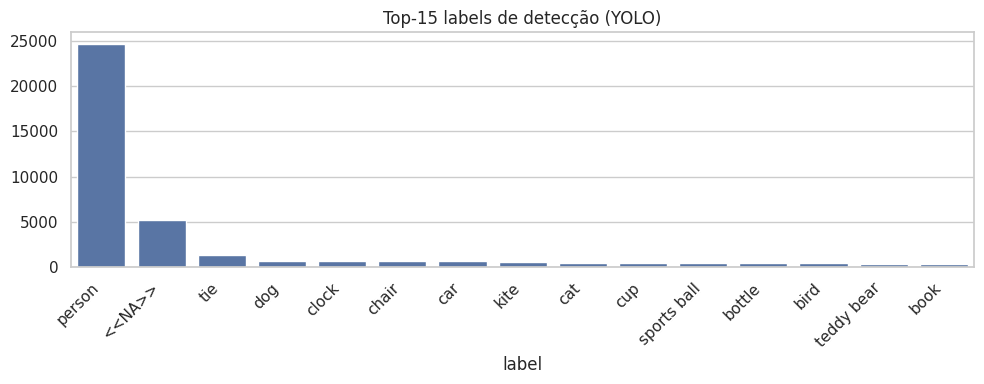


Confiança — média=0.5659, mediana=0.5497, min=0.2500, max=0.9737, N=38806


In [5]:
# Distribuição de labels e confiança
if "label" in df.columns:
    print("\n=== Top‑15 labels ===")
    vc = df["label"].fillna("<<NA>>").value_counts()
    print(vc.head(15))

    plt.figure(figsize=(10, 4))
    sns.barplot(x=vc.head(15).index.astype(str), y=vc.head(15).values)
    plt.xticks(rotation=45, ha="right")
    plt.title("Top‑15 labels de detecção (YOLO)")
    plt.tight_layout()
    plt.show()

if "conf" in df.columns:
    conf = pd.to_numeric(df["conf"], errors="coerce").dropna()
    print(f"\nConfiança — média={conf.mean():.4f}, mediana={conf.median():.4f}, "
          f"min={conf.min():.4f}, max={conf.max():.4f}, N={len(conf)}")

## OCR: Estatísticas e exemplos

In [6]:
if "ocr_text" in df.columns:
    has_ocr = (df["ocr_text"].fillna("").str.strip() != "")
    pct_ocr = float(has_ocr.mean())
    print(f"ocr_text não‑vazio: {pct_ocr:.2%} ({int(has_ocr.sum())}/{len(has_ocr)})")
if "ocr_global_text" in df.columns:
    has_ocr_g = (df["ocr_global_text"].fillna("").str.strip() != "")
    pct_ocr_g = float(has_ocr_g.mean())
    print(f"ocr_global_text não‑vazio: {pct_ocr_g:.2%} ({int(has_ocr_g.sum())}/{len(has_ocr_g)})")

if "ocr_text" in df.columns:
    nonempty = df[df["ocr_text"].fillna("").str.strip() != ""]
    if len(nonempty) > 0:
        cols = [c for c in ["filename", "label", "ocr_text", "ocr_global_text"] if c in df.columns]
        display(nonempty[cols].head(15))
    else:
        print("Nenhuma linha com ocr_text não‑vazio.")
else:
    print("Coluna 'ocr_text' não está presente (provavelmente apenas Stage A carregado).")
    if "ocr_global_text" in df.columns:
        nonempty = df[df["ocr_global_text"].fillna("").str.strip() != ""]
        if len(nonempty) > 0:
            display(nonempty[[c for c in ["filename","label","ocr_global_text"] if c in df.columns]].head(15))

ocr_text não‑vazio: 25.65% (11301/44057)
ocr_global_text não‑vazio: 83.21% (36662/44057)


,filename,label,ocr_text,ocr_global_text
0,35lpk92.jpg,person,heart,might not have or the biggest muscles the pret...
1,35lpk92.jpg,person,whatev have nothing,might not have or the biggest muscles the pret...
2,35lpk92.jpg,person,muscles,might not have or the biggest muscles the pret...
3,35lpk92.jpg,person,or Ine Diggesu muscles Or anything whateve hav...,might not have or the biggest muscles the pret...
6,35lpk92.jpg,person,Jlgui Moi Mcs the prettiest smile or the warme...,might not have or the biggest muscles the pret...
11,lrsfjp72h79c1.jpeg,horse,ust wasn't a y happy child,Ihad a very happy Ijust wasn't a childhood ver...
12,4kub1qz8cp6c1.jpeg,person,[Autism Psychiatrists,Young boyswit ADHDJAutism Psychiatrists Girls ...
13,4kub1qz8cp6c1.jpeg,person,Girls with AL,Young boyswit ADHDJAutism Psychiatrists Girls ...
14,4kub1qz8cp6c1.jpeg,person,ano,Young boyswit ADHDJAutism Psychiatrists Girls ...
18,s25lzver7m7c1.jpeg,person,New year DaveClao New mental Sues,


## Embeddings: validação

In [7]:
if "embedding" in df.columns:
    def _emb_nonzero(x):
        try:
            v = np.array(x, dtype=np.float32)
            return v.size > 0 and np.any(v != 0)
        except Exception:
            return False

    def _emb_dim(x):
        try:
            return np.array(x, dtype=np.float32).size
        except Exception:
            return None

    nz = df["embedding"].apply(_emb_nonzero)
    dims = df["embedding"].apply(_emb_dim).dropna().unique()

    print(f"Embedding — dimensão(s): {dims}")
    print(f"Não‑zero ratio: {float(nz.mean()):.4f} ({int(nz.sum())}/{len(nz)})")

    if nz.sum() == 0:
        print("⚠️  Todos os embeddings são vetores zero. "
              "Verifique se o texto para embedding (ocr_text / ocr_global_text / label) está vazio.")
else:
    print("Coluna 'embedding' não encontrada (apenas Stage A carregado).")

Embedding — dimensão(s): [384]
Não‑zero ratio: 1.0000 (44055/44057)


## Amostras visuais: crops salvos

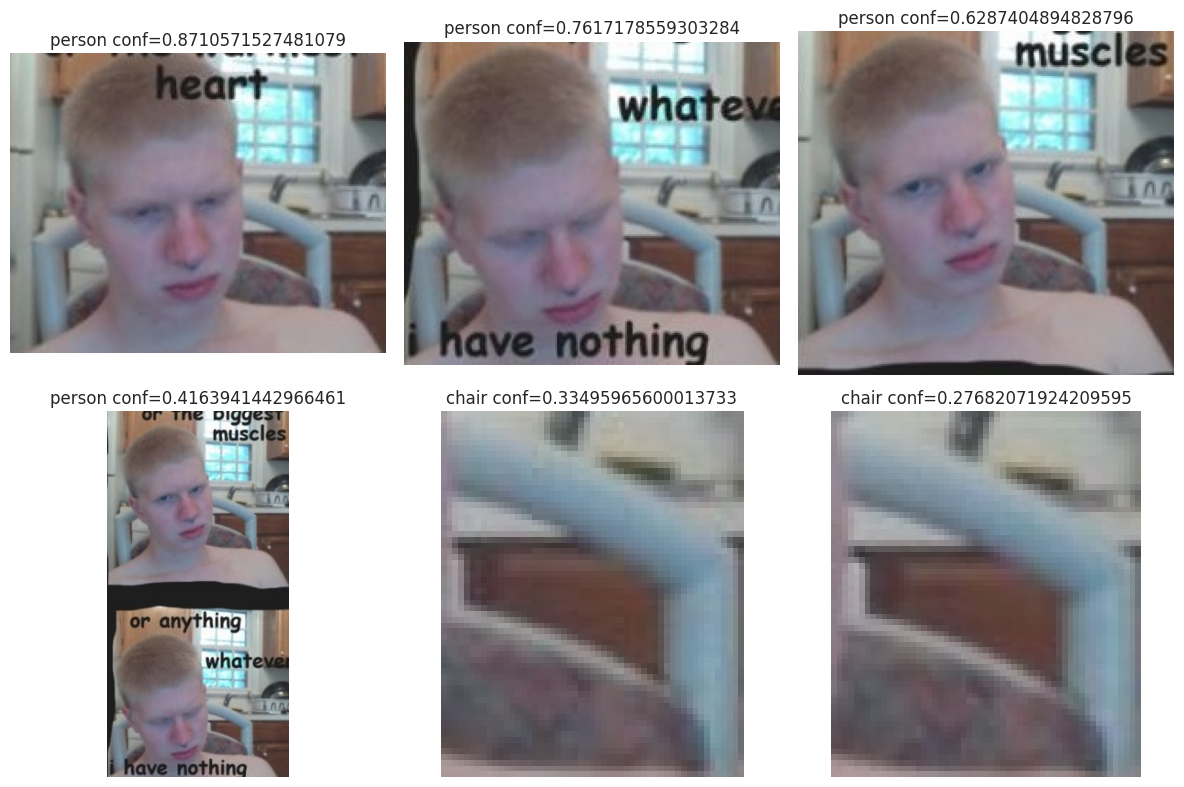

In [8]:
if "crop_path" in df.columns:
    sample_crops = df[df["crop_path"].notna()].head(6)
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    for ax, (_, row) in zip(axes, sample_crops.iterrows()):
        cp = row.get("crop_path")
        if cp and os.path.isfile(cp):
            img = Image.open(cp).convert("RGB")
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "crop não encontrado", ha="center", va="center")
        label = row.get("label") or ""
        conf = row.get("conf") or ""
        ax.set_title(f"{label} conf={conf}" if conf else label)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Coluna 'crop_path' não encontrada.")
    # Fallback: mostrar imagem original com bbox
    print("Exibindo imagens originais com bbox como fallback...")

## Amostras visuais: imagens originais com bounding boxes

Image: 35lpk92.jpg


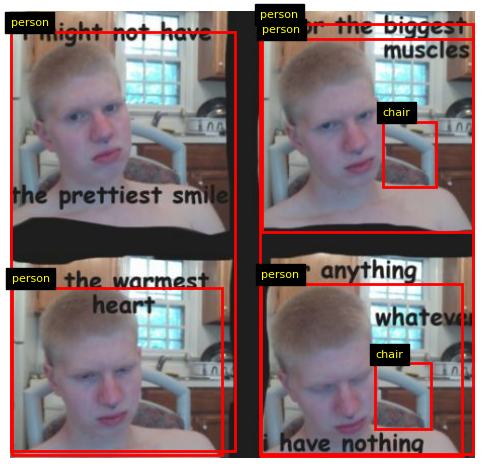

Image: 1ahnl651ta9c1.png


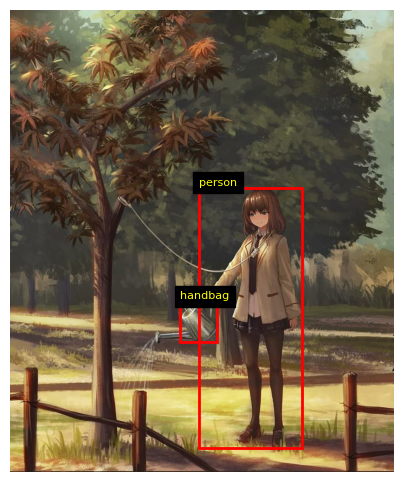

Image: sOusAkV.jpg


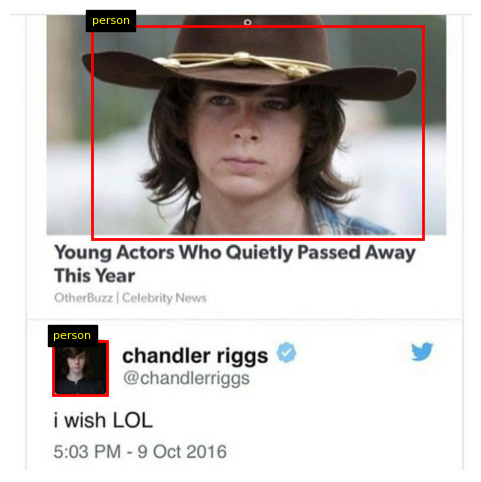

Image: lrsfjp72h79c1.jpeg


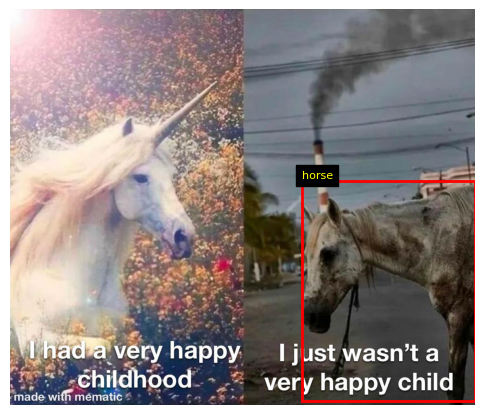

Image: 4kub1qz8cp6c1.jpeg


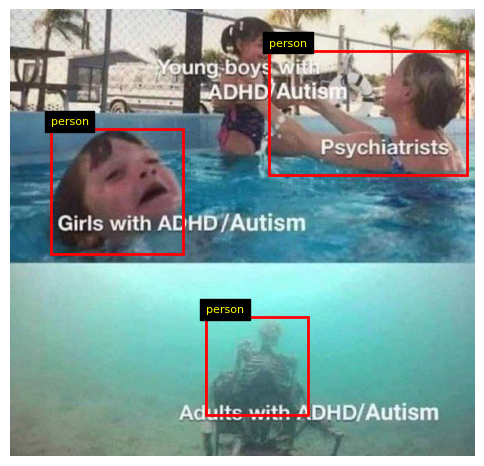

Image: mz6ostmcjlbc1.jpeg


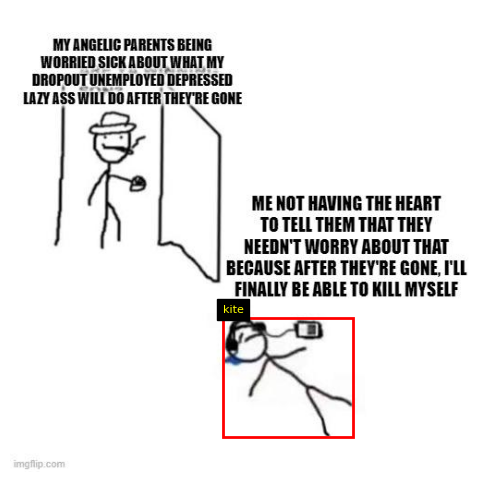

In [9]:
def show_image_with_boxes(image_path, detections):
    if not os.path.isfile(image_path):
        print(f"Arquivo não encontrado: {image_path}")
        return
    img = Image.open(image_path).convert("RGB")
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img)
    for det in detections:
        if not isinstance(det, dict):
            continue
        bbox = det.get("bbox") or det.get("box")
        label = det.get("label") or det.get("detection_type") or ""
        if bbox is None:
            continue
        if len(bbox) == 4:
            x1, y1, x2, y2 = bbox
            w, h = x2 - x1, y2 - y1
        else:
            x1, y1, w, h = bbox
        rect = Rectangle((x1, y1), w, h, linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, max(0, y1 - 6), str(label), color="yellow", fontsize=8,
                backgroundcolor="black")
    plt.axis("off")
    plt.show()

# Pegar até 6 imagens com detecções
if "path" in df.columns:
    unique_paths = df[df["detection_id"].notna() & (df["detection_id"] >= 0)]["path"].drop_duplicates().head(6)
    for p in unique_paths:
        local = str(p).replace("file://", "").replace("file:", "")
        dets = df[df["path"] == p].to_dict(orient="records")
        if local:
            print(f"Image: {os.path.basename(local)}")
            show_image_with_boxes(local, dets)
else:
    print("Coluna 'path' não encontrada.")

## PCA → t‑SNE sobre embeddings

Shape: (3000, 384)


/tmp/ipykernel_1371/3953045629.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


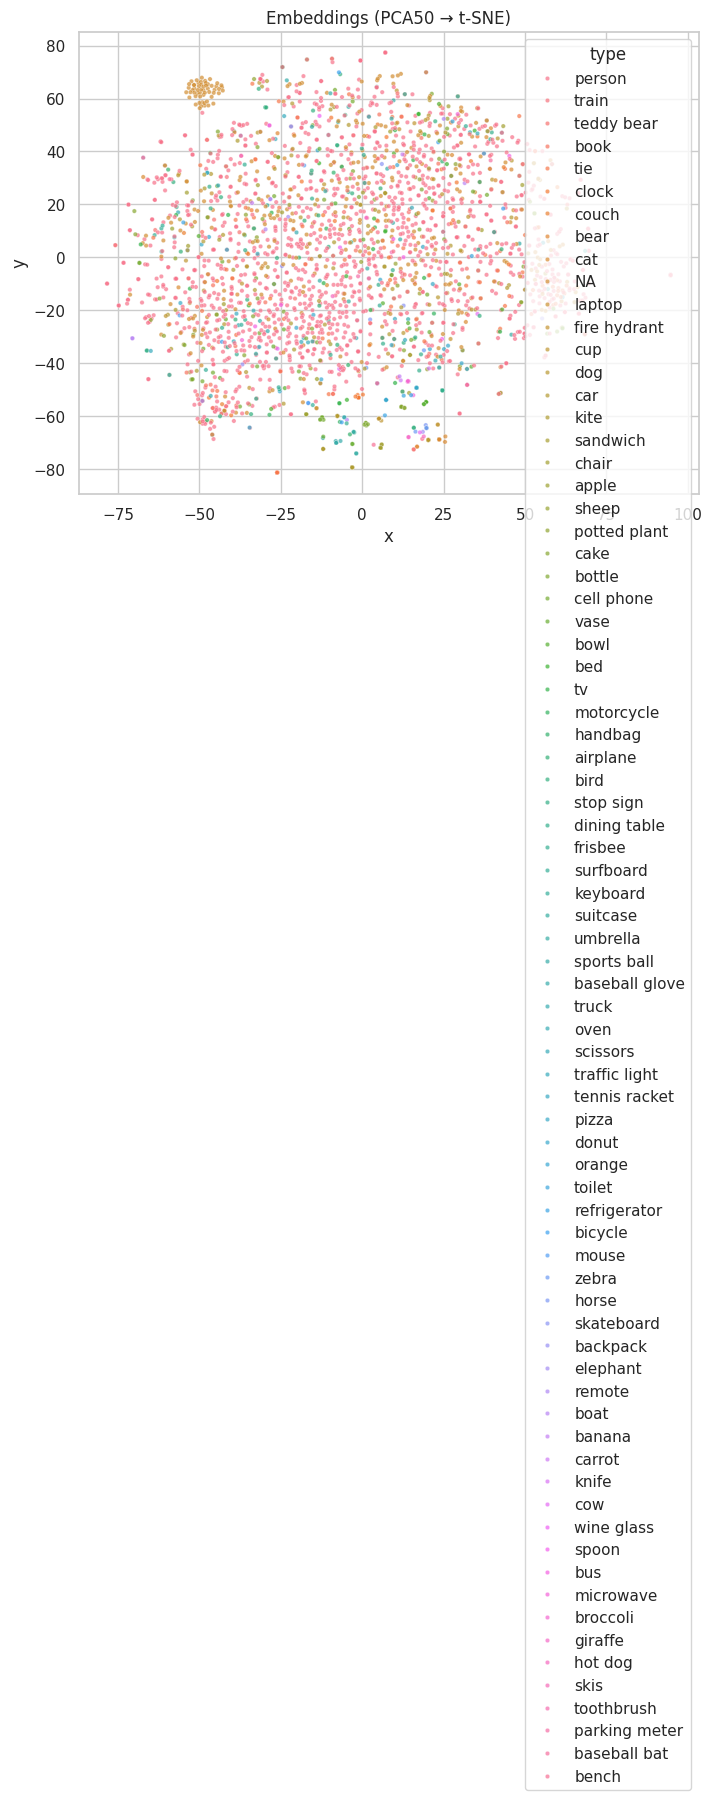

In [10]:
if "embedding" in df.columns:
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE

    valid = df["embedding"].apply(
        lambda x: isinstance(x, (list, np.ndarray)) and len(np.array(x, dtype=np.float32)) > 0 and np.any(np.array(x, dtype=np.float32) != 0)
    )
    sub = df[valid].copy()
    if len(sub) < 10:
        print(f"Poucas embeddings válidas ({len(sub)}), pulando PCA/t-SNE.")
    else:
        if len(sub) > 3000:
            sub = sub.sample(3000, random_state=42)
        embs = np.stack(sub["embedding"].apply(lambda x: np.array(x, dtype=np.float32)))
        print(f"Shape: {embs.shape}")
        embs_pca = PCA(n_components=min(50, *embs.shape)).fit_transform(embs)
        embs_2d = TSNE(n_components=2, init="pca", random_state=42, perplexity=30).fit_transform(embs_pca)

        plot_df = pd.DataFrame({"x": embs_2d[:, 0], "y": embs_2d[:, 1]})
        if "label" in sub.columns:
            plot_df["type"] = sub["label"].fillna("NA").values
        elif "status" in sub.columns:
            plot_df["type"] = sub["status"].values

        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            data=plot_df, x="x", y="y",
            hue="type" if "type" in plot_df.columns else None,
            s=10, alpha=0.7, legend="brief"
        )
        plt.title("Embeddings (PCA50 → t-SNE)")
        if "type" in plot_df.columns and plot_df["type"].nunique() <= 30:
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()
else:
    print("Coluna 'embedding' não encontrada.")

## Busca semântica (nearest neighbors)

In [11]:
if "embedding" in df.columns and df["embedding"].apply(
        lambda x: isinstance(x, (list, np.ndarray)) and len(np.array(x, dtype=np.float32)) > 0
    ).sum() > 0:
    from sentence_transformers import SentenceTransformer

    model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    print("Modelo carregado.")

    # Matriz de embeddings
    valid = df["embedding"].apply(
        lambda x: isinstance(x, (list, np.ndarray)) and len(np.array(x, dtype=np.float32)) > 0 and np.any(np.array(x, dtype=np.float32) != 0)
    )
    embs = np.stack(df[valid]["embedding"].apply(lambda x: np.array(x, dtype=np.float32)))
    norms = np.linalg.norm(embs, axis=1, keepdims=True)
    norms[norms == 0] = 1  # avoid division by zero
    E = embs / norms

    def semantic_search(query, topk=5):
        qv = model.encode([query])[0]
        qv = qv / (np.linalg.norm(qv) + 1e-12)
        sims = (E @ qv).astype(np.float32)
        idx = np.argsort(-sims)[:topk]
        return idx, sims[idx]

    query = input("Digite um termo de busca (ex: 'person', 'food', 'funny'): ") or "person"
    idxs, scores = semantic_search(query)
    candidates = df[valid].iloc[idxs].copy()
    candidates["score"] = scores
    cols = [c for c in ["filename", "label", "ocr_text", "ocr_global_text", "score"] if c in candidates.columns]
    print("\nTop resultados:")
    display(candidates[cols])
else:
    print("Embeddings insuficientes para busca semântica (ou coluna ausente).")

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1781204112.039073    1371 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781204112.096720    1371 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781204113.722384    1371 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point roun

Modelo carregado.


Digite um termo de busca (ex: 'person', 'food', 'funny'):  cat



Top resultados:


,filename,label,ocr_text,ocr_global_text,score
23883,69y0tnpvgj6c1.jpeg,kite,cat,COMMON CAT TYPES idk lagsaga Meow cat EH? Ha!...,1.0
39,icohjdsvro9c1.jpeg,cat,,,1.0
8179,08c6rc778sbc1.jpeg,cat,,,1.0
31566,g2xmy8pfo98c1.jpeg,cat,,,1.0
31565,g2xmy8pfo98c1.jpeg,cat,,,1.0


## Sumário final e exportação

In [12]:
print("=" * 50)
print("SUMÁRIO DO PIPELINE")
print("=" * 50)

n_imgs = df["path"].nunique() if "path" in df.columns else "n/a"
n_dets = len(df)
n_err = df["error"].notna().sum() if "error" in df.columns else 0

if "ocr_text" in df.columns:
    pct_ocr = float((df["ocr_text"].fillna("").str.strip() != "").mean())
else:
    pct_ocr = 0.0

if "embedding" in df.columns:
    pct_emb = float((df["embedding"].apply(
        lambda x: isinstance(x, (list, np.ndarray)) and len(np.array(x, dtype=np.float32)) > 0 and np.any(np.array(x, dtype=np.float32) != 0)
    )).mean())
else:
    pct_emb = 0.0

print(f"  Imagens únicas:     {n_imgs}")
print(f"  Total detecções:    {n_dets}")
print(f"  Linhas com erro:    {n_err}")
print(f"  OCR não‑vazio:      {pct_ocr:.2%}")
print(f"  Embedding não‑zero: {pct_emb:.2%}")

# Exportar amostra de OCR para anotação
out_csv = "/workspace/data/output/text_samples_for_annotation.csv"
if "ocr_text" in df.columns and "label" in df.columns:
    nonempty = df[df["ocr_text"].fillna("").str.strip() != ""]
    if len(nonempty) > 0:
        export_cols = [c for c in ["filename", "label", "ocr_text", "ocr_global_text"] if c in nonempty.columns]
        nonempty[export_cols].head(500).to_csv(out_csv, index=False)
        print(f"\nExportado: {out_csv} ({min(500, len(nonempty))} linhas)")
    else:
        print("\nNada exportado — nenhuma linha com OCR não‑vazio.")
else:
    print("\nNada exportado — colunas ocr_text/label ausentes.")

SUMÁRIO DO PIPELINE
  Imagens únicas:     17780
  Total detecções:    44057
  Linhas com erro:    0
  OCR não‑vazio:      25.65%
  Embedding não‑zero: 100.00%

Exportado: /workspace/data/output/text_samples_for_annotation.csv (500 linhas)
